In [2]:
# import the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df= pd.read_csv("/content/HPQ.csv")

In [7]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14663 entries, 0 to 14662
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       14663 non-null  object 
 1   Open       14663 non-null  float64
 2   High       14663 non-null  float64
 3   Low        14663 non-null  float64
 4   Close      14663 non-null  float64
 5   Adj Close  14663 non-null  float64
 6   Volume     14663 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 802.0+ KB


In [8]:
# Create a new DataFrame with only Date and Close columns
data = df[['Date', 'Close']].copy()

# Display the first 5 rows
data.head()

,Date,Close
0,1962-01-02,0.124177
1,1962-01-03,0.122846
2,1962-01-04,0.120185
3,1962-01-05,0.117525
4,1962-01-08,0.119299


In [9]:
data.rename(columns={'Close': 'Price'}, inplace=True)
data.head()

,Date,Price
0,1962-01-02,0.124177
1,1962-01-03,0.122846
2,1962-01-04,0.120185
3,1962-01-05,0.117525
4,1962-01-08,0.119299


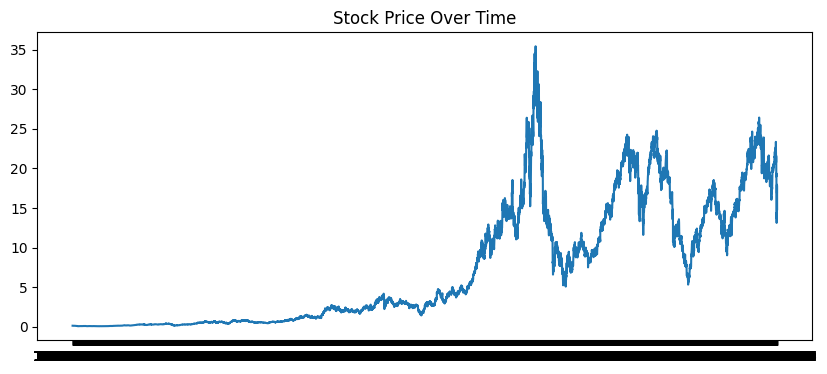

In [10]:
plt.figure(figsize=(10,4))

plt.plot(data['Date'], data['Price'])

plt.title('Stock Price Over Time')

plt.show()

<Figure size 3000x500 with 0 Axes>

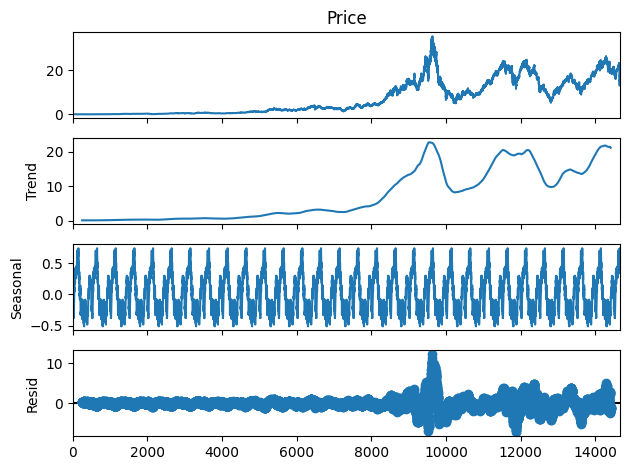

In [11]:
# Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(30,5))

decomposition = seasonal_decompose(
    data['Price'],
    model='additive',
    period=500
)

decomposition.plot()

plt.show()

In [12]:
scalar = MinMaxScaler()

scaled_prices = scalar.fit_transform(data[['Price']])

scaled_prices

array([[0.00198119],
       [0.00194357],
       [0.00186834],
       ...,
       [0.50287759],
       [0.4893061 ],
       [0.41805572]])

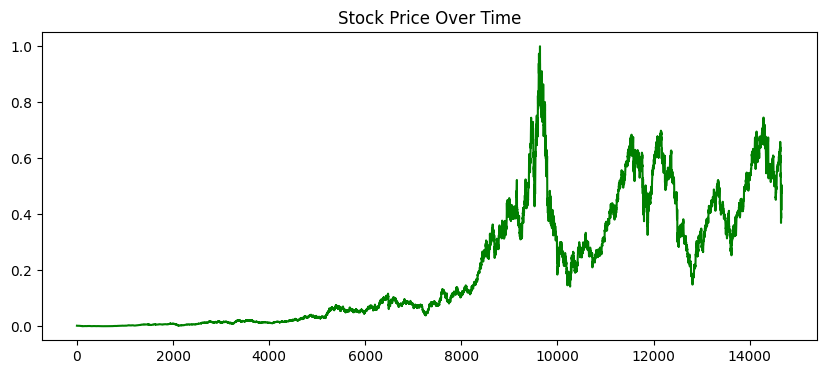

In [13]:
plt.figure(figsize=(10,4))

plt.plot(scaled_prices, color="green")

plt.title('Stock Price Over Time')

plt.show()

In [17]:
def create_sequence(series, lookback=60):
    X, y = [],[]

    for i in range(lookback, len(series)):
        X.append(series[i-lookback:i, 0])
        y.append(series[i, 0])

    return np.array(X), np.array(y)


In [18]:

LOOKBACK = 60

X, y = create_sequence(scaled_prices, LOOKBACK)

In [19]:
X

array([[0.00198119, 0.00194357, 0.00186834, ..., 0.00195611, 0.00189342,
        0.0018558 ],
       [0.00194357, 0.00186834, 0.0017931 , ..., 0.00189342, 0.0018558 ,
        0.00189342],
       [0.00186834, 0.0017931 , 0.00184326, ..., 0.0018558 , 0.00189342,
        0.00189342],
       ...,
       [0.58628578, 0.57893454, 0.58119646, ..., 0.43332366, 0.50570499,
        0.47516912],
       [0.57893454, 0.58119646, 0.58261013, ..., 0.50570499, 0.47516912,
        0.50287759],
       [0.58119646, 0.58261013, 0.59024411, ..., 0.47516912, 0.50287759,
        0.4893061 ]])

In [20]:
X.shape

(14603, 60)

In [21]:
y.shape

(14603,)

In [22]:
# reshape this into 3D array for RNN and LSTM
# (samples, timesteps, features => price)

X = X.reshape(X.shape[0], X.shape[1], 1)

X.shape

(14603, 60, 1)

In [23]:
# we can divide the data in 80-20 format

split = int(0.8 * len(X))

split

11682

In [24]:
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [25]:
print(len(X_train), len(X_test))

11682 2921


In [26]:
X_train.shape

(11682, 60, 1)

In [27]:
X_test.shape

(2921, 60, 1)

In [28]:
# RNN Model

rnn_model = Sequential([
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(LOOKBACK, 1)
    ),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
rnn_model.compile(
    optimizer="adam",
    loss="mse"
)

In [31]:
# Training

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 3.7275e-04 - val_loss: 2.7218e-04
Epoch 2/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.0947e-04 - val_loss: 2.5781e-04
Epoch 3/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9.0075e-05 - val_loss: 1.7259e-04
Epoch 4/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 8.0313e-05 - val_loss: 1.4758e-04
Epoch 5/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 7.5331e-05 - val_loss: 1.4176e-04
Epoch 6/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 6.2490e-05 - val_loss: 1.3084e-04
Epoch 7/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 6.9715e-05 - val_loss: 1.4244e-04
Epoch 8/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 6.1645e-05 - val_loss: 1.3869e-04
Epoch 9/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5.5372e-05 - val_loss: 1.1791e-04
Epoch 10/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 5.2734e-05 - val_loss: 1.5065e-04
Epoch 11/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/

In [41]:
2.2837e-04

0.00022837

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(
        50,
        return_sequences=True,
        input_shape=(LOOKBACK, 1)
    ),
    Dropout(0.2),
    LSTM(50),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - loss: 9.9876e-04 - val_loss: 5.0541e-04
Epoch 2/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - loss: 2.5220e-04 - val_loss: 7.3801e-04
Epoch 3/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - loss: 2.1848e-04 - val_loss: 3.8780e-04
Epoch 4/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - loss: 1.8306e-04 - val_loss: 3.4429e-04
Epoch 5/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - loss: 1.9768e-04 - val_loss: 5.1175e-04
Epoch 6/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - loss: 1.7292e-04 - val_loss: 3.6379e-04
Epoch 7/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - loss: 1.6628e-04 - val_loss: 2.6011e-04
Epoch 8/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - loss: 1.6466e-04 - val_loss: 2.5077e-04
Epoch 9/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - loss: 1.5116e-04 - val_loss: 4.1277e-04
Epoch 10/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - loss: 1.2856e-04 - val_loss: 2.1506e-04
Epoch 11/20
366/366 ━━━━━━━━━━━━━━━━━━━

In [42]:
1.3699e-04

0.00013699

In [33]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [34]:
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - loss: 1.1927e-04 - val_loss: 1.6312e-04
Epoch 2/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 1.0413e-04 - val_loss: 1.3286e-04
Epoch 3/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - loss: 1.0665e-04 - val_loss: 2.1181e-04
Epoch 4/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - loss: 9.7356e-05 - val_loss: 1.7417e-04
Epoch 5/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - loss: 9.9953e-05 - val_loss: 1.3773e-04
Epoch 6/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 9.2457e-05 - val_loss: 1.2848e-04
Epoch 7/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 9.0493e-05 - val_loss: 1.5015e-04
Epoch 8/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 9.5711e-05 - val_loss: 1.6600e-04
Epoch 9/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - loss: 9.1487e-05 - val_loss: 1.1329e-04
Epoch 10/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - loss: 8.9615e-05 - val_loss: 1.3276e-04
Epoch 11/20
366/366 ━━━━━━━━━━━━━━━━━━━

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(model, X, y, name="Model"):
    pred = model.predict(X)

    # Inverse transform
    pred_rescaled = scalar.inverse_transform(pred)
    y_rescaled = scalar.inverse_transform(
        y.reshape(-1, 1)
    )

    # Metrics
    mae = mean_absolute_error(
        y_rescaled,
        pred_rescaled
    )

    mse = mean_squared_error(
        y_rescaled,
        pred_rescaled
    )

    print(f"MAE: {mae}, MSE: {mse}")

    return pred_rescaled, y_rescaled

In [36]:
rnn_pred, rnn_y = evaluate(
    rnn_model,
    X_test,
    y_test,
    "RNN"
)

lstm_pred, lstm_y = evaluate(
    lstm_model,
    X_test,
    y_test,
    "LSTM"
)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MAE: 0.42797305705571004, MSE: 0.28566981613502856
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
MAE: 0.24055591293982714, MSE: 0.13254945309857794


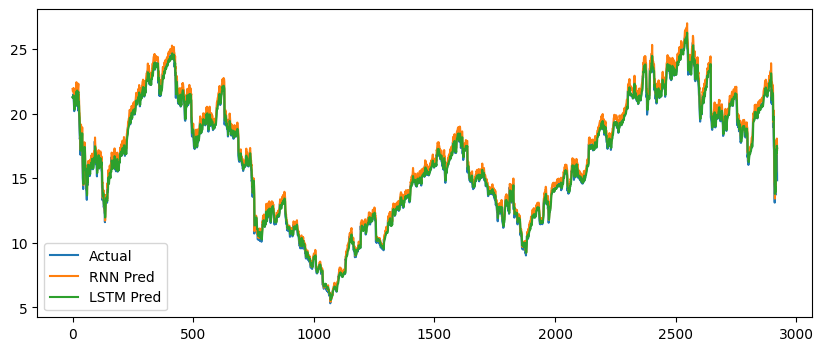

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(rnn_y, label="Actual")
plt.plot(rnn_pred, label="RNN Pred")
plt.plot(lstm_pred, label="LSTM Pred")

plt.legend()
plt.show()

In [46]:
# Forecasting
future_days = 420

last_window = scaled_prices[-LOOKBACK:]
future_pred = []

window = last_window.copy()

LOOKBACK = 60

In [47]:
for i in range(future_days):
    x_input = window.reshape(1, LOOKBACK, 1)

    pred = lstm_model.predict(x_input)[0, 0]

    future_pred.append(pred)

    window = np.append(
        window[1:],
        pred
    ).reshape(-1, 1)

future_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

[np.float32(0.43619764),
 np.float32(0.43629214),
 np.float32(0.43939945),
 np.float32(0.44279054),
 np.float32(0.44572777),
 np.float32(0.4480833),
 np.float32(0.4499212),
 np.float32(0.45136184),
 np.float32(0.45252553),
 np.float32(0.45350915),
 np.float32(0.4543818),
 np.float32(0.45518884),
 np.float32(0.45595372),
 np.float32(0.4566831),
 np.float32(0.45737666),
 np.float32(0.4580294),
 np.float32(0.45863596),
 np.float32(0.45919034),
 np.float32(0.45968756),
 np.float32(0.46012735),
 np.float32(0.4605119),
 np.float32(0.4608438),
 np.float32(0.46112454),
 np.float32(0.46135747),
 np.float32(0.46154937),
 np.float32(0.46170703),
 np.float32(0.46183455),
 np.float32(0.4619363),
 np.float32(0.46201557),
 np.float32(0.462077),
 np.float32(0.4621263),
 np.float32(0.46216685),
 np.float32(0.46219963),
 np.float32(0.46223867),
 np.float32(0.46229264),
 np.float32(0.4623583),
 np.float32(0.46242967),
 np.float32(0.46250975),
 np.float32(0.46259713),
 np.float32(0.46269566),
 np.float32(

In [48]:
future_stock_price = scalar.inverse_transform(np.array(future_pred).reshape(-1, 1))
future_stock_price

array([[15.4816475],
       [15.48499  ],
       [15.594891 ],
       [15.714828 ],
       [15.818711 ],
       [15.902023 ],
       [15.967026 ],
       [16.017979 ],
       [16.059137 ],
       [16.093925 ],
       [16.12479  ],
       [16.153334 ],
       [16.180386 ],
       [16.206182 ],
       [16.230713 ],
       [16.253798 ],
       [16.275251 ],
       [16.294859 ],
       [16.312445 ],
       [16.328    ],
       [16.3416   ],
       [16.35334  ],
       [16.363268 ],
       [16.371508 ],
       [16.378294 ],
       [16.38387  ],
       [16.38838  ],
       [16.39198  ],
       [16.394783 ],
       [16.396955 ],
       [16.398699 ],
       [16.400133 ],
       [16.401293 ],
       [16.402674 ],
       [16.404583 ],
       [16.406904 ],
       [16.40943  ],
       [16.41226  ],
       [16.415352 ],
       [16.418837 ],
       [16.423136 ],
       [16.428442 ],
       [16.434525 ],
       [16.44137  ],
       [16.449602 ],
       [16.459185 ],
       [16.469767 ],
       [16.48

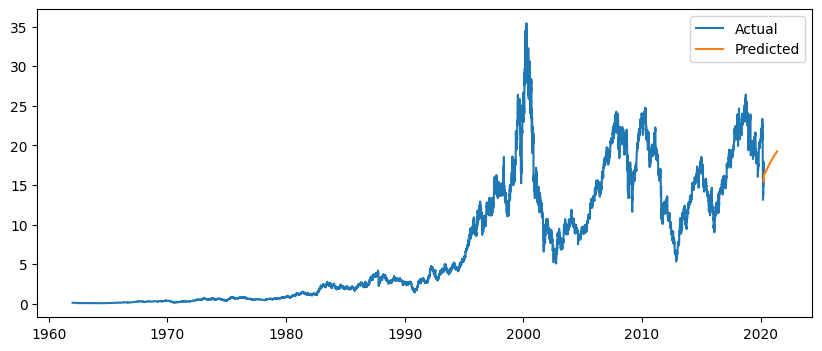

In [49]:
plt.figure(figsize=(10, 4))

# Convert 'Date' column to datetime objects
data['Date'] = pd.to_datetime(data['Date'])

plt.plot(
    data['Date'],
    data['Price'],
    label="Actual"
)

future_dates = pd.date_range(
    start=data['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=future_days,
    freq="D"
)

plt.plot(
    future_dates,
    future_stock_price,
    label="Predicted"
)

plt.legend()
plt.show()